In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc= pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\spectral_trait_mean.csv")
df_svc_pc=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\diff\spectral_trait_mean_pc.csv")
df_svc_pn=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\diff\spectral_trait_mean_pn.csv")
df_svc_sla=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\diff\spectral_trait_mean_sla.csv")
df_svc_d13c=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\diff\spectral_trait_mean_d13c.csv")
# df_svc_la= pd.read_csv(r"D:\wenqu\2024_data\SVC\update2\T-squared\spectral_trait_mean.csv")
df_svc_d15n=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\diff\spectral_trait_mean_d15n.csv")
df_svc_ldmc=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\diff\spectral_trait_mean_ldmc.csv")
# df_svc_la

In [3]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    b_std = 'd' + str(i) 
    b_name.append(b_std)
    # b_std = 'b' + str(i) + '_std'
    # b_name.append(b_std)


b_name = np.array(b_name)
# b_name

In [4]:
x_d13c = np.array(df_svc_d13c[b_name])
x_d15n = np.array(df_svc_d15n[b_name])
x_ldmc = np.array(df_svc_ldmc[b_name])
x_pc = np.array(df_svc_pc[b_name])
x_pn = np.array(df_svc_pn[b_name])
x_sla = np.array(df_svc_sla[b_name])
# x_la = np.array(df_svc_la[b_name])

In [5]:
df_svc_d13c

,site,CWM_Ld13C,CWM_Ld15N,CWM_log10_LA,CWM_log10_SLA,CWM_log10_PN,CWM_log10_LDMC,CWM_log10_PC,b1,b2,...,d112,d113,d114,d115,d116,d117,d118,d119,d120,d121
0,S3C_Q02,-28.493357,-1.008321,0.328341,0.982212,1.192394,2.679461,2.662491,0.011361,0.011405,...,-0.000345,0.000864,0.002651,0.001494,-0.000008,-0.000695,0.001161,-0.001663,-0.000466,-0.003447
1,S3C_Q03,-29.244686,-4.591383,-0.106780,0.447457,0.984538,2.810259,2.657785,0.023802,0.024319,...,0.003767,0.002197,0.002969,0.001223,-0.001356,-0.000662,-0.000596,-0.001527,-0.002291,-0.005429
2,S3C_Q04,-28.446174,-1.313879,0.153008,0.667112,1.125512,2.714658,2.641835,0.028783,0.029309,...,0.002452,0.002152,0.003528,0.004276,0.000889,0.000048,0.000140,-0.000371,-0.000372,-0.003971
3,S3C_Q05,-28.453987,-2.819253,-0.107205,0.509009,1.106397,2.474649,2.648293,0.022247,0.023094,...,0.002910,0.001579,0.003337,0.004498,0.001915,-0.003498,0.001664,-0.002720,0.006929,-0.010322
4,S3C_Q07,-28.669745,-2.069676,0.351740,0.673271,1.107105,2.701362,2.641516,0.021825,0.022113,...,0.000400,0.001668,0.002134,-0.001011,-0.000906,0.001331,-0.000398,-0.002463,-0.000923,-0.003791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,S1B_Q32,-27.741047,-0.975923,0.828249,1.025977,1.324210,2.607794,2.686539,0.008917,0.007457,...,0.006775,-0.007815,0.018328,-0.018650,0.014474,-0.015738,-0.003998,-0.000795,-0.004264,-0.033520
118,S2C_Q01,-27.997066,2.215618,0.927549,0.791126,1.188391,2.729070,2.664670,0.023235,0.020013,...,-0.004110,0.005034,0.003701,0.006603,-0.005207,-0.000616,0.002146,-0.004009,0.000409,-0.004218
119,S2C_Q02,-26.680322,3.394480,1.132447,0.792150,1.157011,2.819904,2.664165,0.018854,0.021207,...,-0.007177,0.001930,0.012268,0.010648,-0.014220,0.006150,0.005944,0.004396,0.002174,-0.014881
120,S2C_Q03,-27.625914,2.497644,0.711165,0.815534,1.199038,2.713769,2.674433,0.019624,0.011369,...,-0.004068,-0.007941,0.005712,0.007090,0.000903,0.002743,-0.005567,-0.000885,0.003363,-0.005804


In [6]:
# labels_la = [] 
# for i in range(len(df_svc_la['site'])):    
#     site_name = df_svc_la['site'][i].split("_")[0]
#     labels_la.append(site_name)


labels_d13c = [] 
for i in range(len(df_svc_d13c['site'])):    
    site_name = df_svc_d13c['site'][i].split("_")[0]
    labels_d13c.append(site_name)


labels_d15n = [] 
for i in range(len(df_svc_d15n['site'])):    
    site_name = df_svc_d15n['site'][i].split("_")[0]
    labels_d15n.append(site_name)


labels_ldmc = [] 
for i in range(len(df_svc_ldmc['site'])):    
    site_name = df_svc_ldmc['site'][i].split("_")[0]
    labels_ldmc.append(site_name)

In [7]:
labels_pc = [] 
for i in range(len(df_svc_pc['site'])):    
    site_name = df_svc_pc['site'][i].split("_")[0]
    labels_pc.append(site_name)
# labels_pc

labels_pn = [] 
for i in range(len(df_svc_pn['site'])):    
    site_name = df_svc_pn['site'][i].split("_")[0]
    labels_pn.append(site_name)


labels_sla = [] 
for i in range(len(df_svc_sla['site'])):    
    site_name = df_svc_sla['site'][i].split("_")[0]
    labels_sla.append(site_name)

In [8]:
y_d13c = df_svc_d13c['CWM_Ld13C'].to_numpy()
y_d15n = df_svc_d15n['CWM_Ld15N'].to_numpy()
y_ldmc = df_svc_ldmc['CWM_log10_LDMC'].to_numpy()
y_pc = df_svc_pc['CWM_log10_PC'].to_numpy()
y_pn = df_svc_pn['CWM_log10_PN'].to_numpy()
y_sla = df_svc_sla['CWM_log10_SLA'].to_numpy()
# y_la = df_svc_la['CWM_log10_LA'].to_numpy()

In [9]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=10)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [10]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## pc

In [11]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_pc, y_pc, 20)


Optimised number of PLS components:  11
Wavelengths to be kept  32
Optimised MSEP  0.022315530713690215



[2.64763298 2.67527123 2.65413669 2.63514515 2.64935161 2.6317024
 2.65413826 2.63689875 2.64617636 2.64968905 2.62815566 2.63931364
 2.64016293 2.63941164 2.65037761 2.65769792 2.64495    2.63658807
 2.64015695 2.64754159 2.66451996 2.65039237 2.67958648 2.65592501
 2.65864028 2.65802872 2.67087802 2.6523096  2.6461998  2.64923959
 2.65143422 2.64643309 2.66286813 2.66155322 2.66418648 2.65680822
 2.62625856 2.65570353 2.67597479 2.6702136  2.6519593  2.64414852
 2.66075435 2.66975303 2.66893846 2.63708638 2.63322702 2.63800331
 2.63464369 2.63720705 2.63434915 2.66463114 2.63219662 2.65445143
 2.64104648 2.64164536 2.64341237 2.63646157 2.64664877 2.63346784
 2.65010612 2.64007509 2.62943937 2.6515445  2.63799274 2.64659574
 2.64530215 2.6337193  2.63171684 2.63429995 2.63160245 2.64153562
 2.64450295 2.61937755 2.61613034 2.62500814 2.6500566  2.62206461
 2.6318403  2.64443233 2.64691122 2.65849698 2.64224778 2.64114865
 2.64664226 2.64779699 2.63237562 2.64967425 2.64084671 2.63703

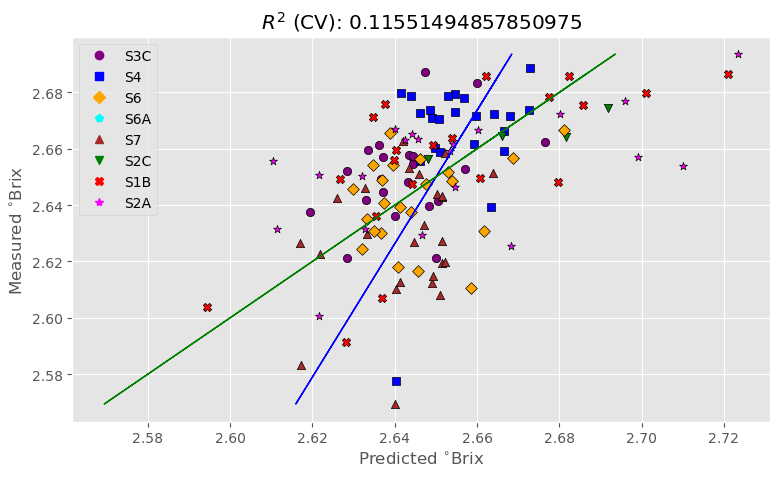

In [12]:
file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\pc.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_pc,                         
                             ncomp, labels_pc, file_name_sla)

## pn

In [13]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_pn, y_pn, 25)


Optimised number of PLS components:  18
Wavelengths to be kept  26
Optimised MSEP  0.09719573837300098



[1.16821356 0.99626331 1.0687141  1.08045895 1.10584968 1.07278279
 1.02990545 1.12377024 0.98005132 1.02397141 1.15702157 1.10168519
 1.12026792 1.09150629 0.96755588 1.08815719 1.12072424 1.01508586
 0.97800277 1.26272551 1.24203303 1.44595552 1.21213468 1.15576418
 1.10866925 1.16704022 1.11036584 1.13761764 1.14439525 1.12838031
 1.2826026  1.24851439 1.20844281 1.07395449 1.12764015 1.39473232
 1.05628765 1.13052679 1.1294198  1.15662373 1.06088234 1.2113286
 1.2843138  1.23151656 1.10804566 1.02840945 1.07271118 1.1597673
 1.16705113 1.10356806 1.2328354  1.18596422 1.14355104 1.18257087
 1.18120849 1.18281808 1.06654197 0.99022187 1.24639534 1.19340314
 1.21825592 1.15491826 1.08559733 1.2108696  1.220963   1.22588013
 1.26888353 1.18080639 1.21801699 1.22084474 1.1633502  1.22469111
 1.17514909 1.15404921 1.16431715 1.16990153 1.24781107 1.09086052
 1.18442539 1.23132112 1.2303516  1.1702674  1.17142448 1.15393518
 1.23940156 1.34373897 1.00042331 1.31302795 0.89368063 1.088758

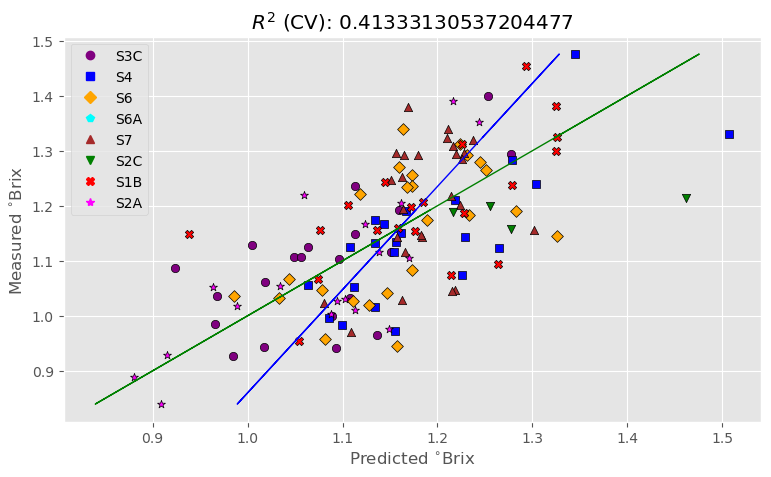

In [14]:
file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\pn.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_pn,                         
                             ncomp, labels_pn, file_name_sla)

## sla
 

In [11]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_sla, y_sla, 25)


Optimised number of PLS components:  14
Wavelengths to be kept  56
Optimised MSEP  0.16355561712402306



[0.96314678 0.90071621 0.41874092 0.6551685  0.71024454 0.67955663
 0.63986452 0.6811635  0.86216149 0.50437182 0.44545385 0.87625252
 0.74398862 0.6048183  0.79907305 0.56764846 0.47869051 0.49097702
 0.64633945 0.93286332 0.94644434 1.13960744 1.05346634 0.93922197
 0.78793663 0.82165289 0.86410879 0.74642254 0.99219868 0.67280775
 1.10971325 0.91343026 0.71961768 0.73343725 1.07645835 0.70418802
 0.79237442 0.83930992 0.6397168  0.64807339 0.76129657 0.8423389
 0.84213364 0.99528277 0.82281676 0.52436779 0.56420259 0.61767817
 0.89085683 0.34094795 1.03054406 0.67168875 0.9353524  0.89796703
 1.03411705 0.5293817  0.87912812 0.79187488 1.01547832 0.91179598
 0.72319098 1.03761995 1.06470774 1.02764222 1.27851787 0.95285383
 0.96629504 0.88493509 0.90387196 0.96743721 0.74845627 0.91666176
 0.910124   0.90663236 1.09719522 0.85227438 1.06043685 1.08019311
 1.05185263 0.87587049 0.86975487 0.91326097 0.21566455 0.1652468
 0.40809176 0.67522137 0.82289813 0.72805316 0.62174952 0.420335

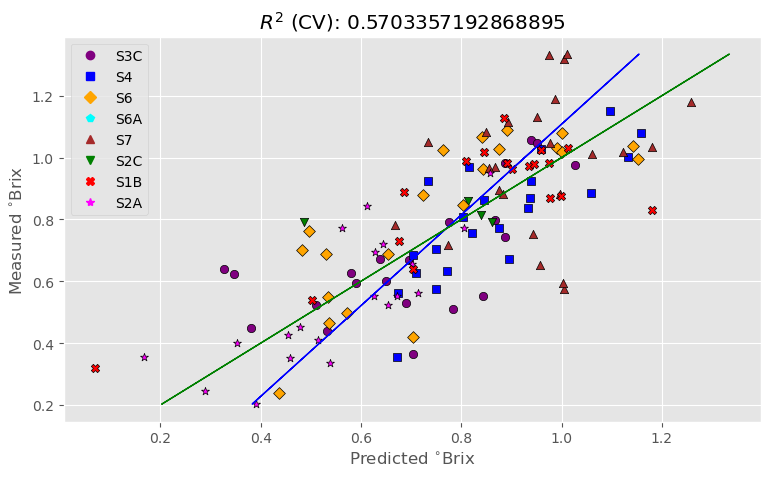

In [16]:
file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\sla.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_sla,                         
                             ncomp, labels_sla, file_name_sla)

In [12]:
optimal_pls = PLSRegression(n_components = 14)
optimal_pls.fit(opt_Xc, y_sla.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(b_name)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

(56,) (56,)


array([-4.76749778e-02,  4.93437756e-02,  4.04726047e-02,  1.12099957e-01,
        3.14166030e-02, -1.82895099e-02,  5.49144654e-02, -6.10237710e-02,
        6.71142103e-03,  4.23289241e-02,  5.18053005e-02, -8.60215197e-02,
        1.51031146e-02, -2.72635826e-02,  2.01868955e-02,  2.81726604e-02,
       -4.52587668e-02, -6.89420842e-02, -2.46087822e-02, -6.66014283e-03,
        6.24034791e-02,  4.00149293e-02, -2.55940199e-02,  1.61356867e-02,
       -5.79386766e-02, -4.39998948e-02,  2.65550506e-02, -2.86946885e-02,
       -5.59722740e-02, -4.95782851e-02,  5.27062811e-02,  2.60220040e-02,
        5.48549422e-02, -7.01856101e-02, -5.00179400e-02, -8.28914185e-02,
        6.76409910e-02, -4.23965190e-02,  5.61588936e-02,  6.73817074e-05,
       -8.21847152e-02,  8.02388102e-02,  3.90320850e-02, -9.18617189e-02,
        7.77306264e-02, -6.50167562e-02, -9.02353681e-02,  7.45511257e-02,
        1.05188163e-01, -1.00054266e-01,  9.45125033e-02, -8.75217382e-02,
        1.22296008e-01, -

In [13]:
optimal_pls.intercept_

array([0.78645784])

In [14]:
bands

array(['d115', 'd67', 'd22', 'd41', 'd8', 'd39', 'd68', 'd53', 'd90',
       'd95', 'd51', 'b2', 'd102', 'd46', 'd86', 'd114', 'd12', 'd99',
       'd85', 'd104', 'd40', 'd21', 'd75', 'd16', 'd43', 'd20', 'd82',
       'd49', 'd76', 'd27', 'd89', 'd37', 'd120', 'd78', 'd87', 'd11',
       'd2', 'd96', 'd30', 'd32', 'd116', 'd29', 'd31', 'd25', 'd28',
       'd24', 'd26', 'd4', 'd72', 'd45', 'd15', 'd113', 'd54', 'd112',
       'd5', 'd57'], dtype='<U4')

## d13c

In [15]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_d13c, y_d13c, 20)


Optimised number of PLS components:  16
Wavelengths to be kept  34
Optimised MSEP  0.6195075168698037



[-28.71248072 -28.89553665 -28.64380291 -28.10631207 -28.29931797
 -28.63309992 -28.7096111  -29.37123598 -28.66627494 -28.32266695
 -28.51655306 -29.09203386 -28.52979968 -28.62685882 -28.42777678
 -28.93328574 -28.7025857  -28.23560686 -28.34313452 -28.26915146
 -28.28435905 -28.8324234  -28.50078063 -28.64110027 -28.84514741
 -28.80319221 -28.69022445 -28.40302888 -28.0821746  -28.72056442
 -28.09116252 -28.55598142 -28.54120111 -27.93768556 -28.48243887
 -28.70916047 -28.42057669 -28.7439867  -28.66547817 -28.48228886
 -28.56132604 -28.02648379 -28.37299816 -28.49810678 -28.52688297
 -28.52817191 -28.62677417 -28.43427088 -29.40937248 -28.42676223
 -28.52225671 -28.30319722 -28.3986859  -28.67753978 -27.97352535
 -27.56783117 -28.60581169 -28.24976391 -28.65828441 -28.26638498
 -28.17283292 -28.42873425 -28.19068565 -28.61157917 -28.9767779
 -28.63036417 -28.51874321 -28.64778985 -28.78418267 -28.83187086
 -28.46588021 -27.71729073 -28.17725289 -27.99213987 -28.09758241
 -27.714628

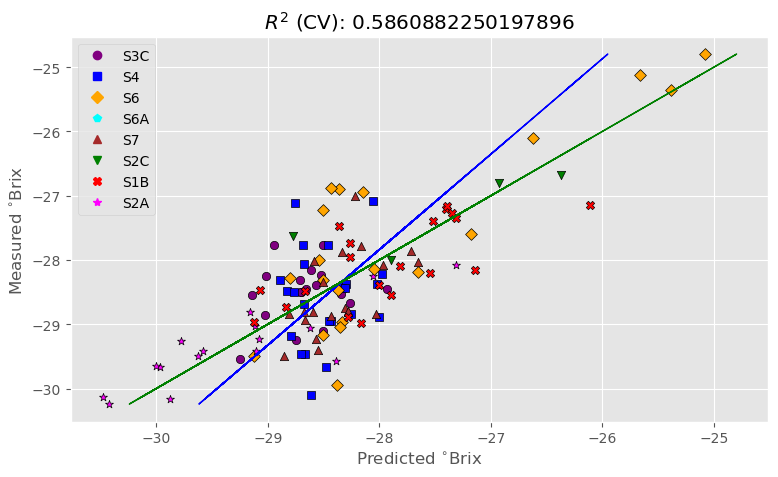

In [18]:
file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\d13c.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_d13c,                         
                             ncomp, labels_d13c, file_name_sla)

In [16]:
optimal_pls = PLSRegression(n_components = 16)
optimal_pls.fit(opt_Xc, y_d13c.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(b_name)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

(34,) (34,)


array([-0.39111748,  0.19864669, -0.17497574, -0.09541043,  0.22541896,
       -0.14439625,  0.07111045,  0.26522289,  0.27814681, -0.22905486,
       -0.26977549, -0.30276334, -0.35533524,  0.10643337, -0.30313541,
       -0.18417121, -0.4860468 ,  0.10369952, -0.21971126,  0.22450294,
       -0.42523145,  0.05941827, -0.37641682,  0.43155013, -0.27372444,
        0.26025664,  0.23864038, -0.24395686,  0.42598708, -0.37020723,
       -0.46567479,  0.19949942, -0.18378538,  0.1907053 ])

In [17]:
optimal_pls.intercept_

array([-28.37217367])

In [18]:
bands

array(['d40', 'd7', 'd37', 'd4', 'd78', 'd118', 'd44', 'd39', 'd120',
       'd87', 'd108', 'd109', 'd100', 'd9', 'd94', 'd105', 'd41', 'd92',
       'd112', 'd43', 'd27', 'd42', 'd52', 'd32', 'd107', 'd5', 'd56',
       'd1', 'd95', 'd30', 'd113', 'd93', 'd104', 'd81'], dtype='<U4')

# d15n

In [19]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_d15n, y_d15n, 25)


Optimised number of PLS components:  8
Wavelengths to be kept  32
Optimised MSEP  1.6637786997812212



[-0.9657685  -2.9346088  -1.1513445  -2.09090101 -0.89680896 -2.8011425
 -2.25224564 -2.5299575  -3.52643303 -2.08814859 -0.82853555 -1.70778179
 -1.10443969 -2.51802599 -3.36541821 -1.74379639 -0.87342487 -2.45964316
 -2.4024827  -1.10424622 -0.32955462 -1.80641931 -2.40934338 -3.19067665
 -3.65431546 -3.03656366 -1.74952219 -2.71878779 -0.70471105 -2.7153111
 -3.13918773 -2.5376116  -4.73717856 -3.84854048 -2.34590627 -3.84490184
 -3.96940198 -3.08863612 -0.20262738 -2.62828593 -2.34459845 -2.07888087
 -2.93800112 -0.77140615  2.53173208 -0.96185282  0.22835449 -3.96185226
 -0.81478214 -0.98733201 -4.23509421  1.129928   -2.00081365 -1.02315174
 -2.47145906 -2.0153002  -0.98590632 -1.05250193 -0.30607991 -0.99524836
 -1.1019359  -0.33776145 -1.79414675 -0.49755959 -0.02856685 -1.19923542
 -1.10723698 -1.71555213  0.07482506 -1.68659652 -1.00477048 -0.958451
  0.06316632  0.26421475 -1.04581835 -0.17039414 -1.29533221  0.07293069
 -0.80478772  0.91367036 -1.46208221 -0.96633232 -4.259

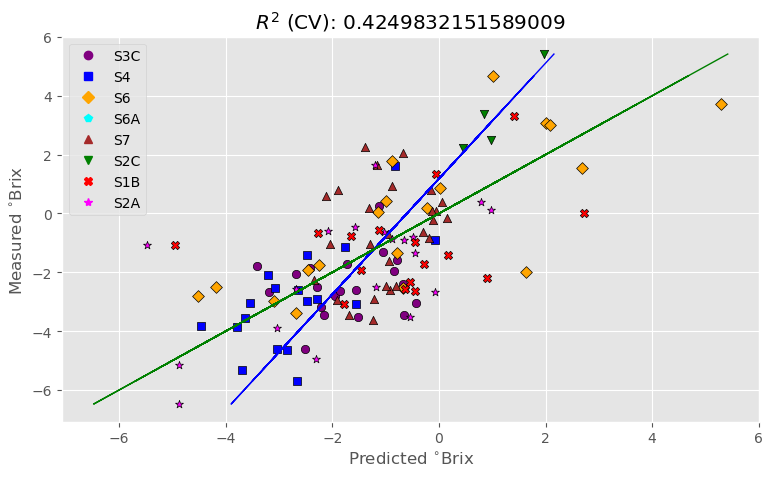

In [20]:

file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\d15n.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_d15n,                         
                             ncomp, labels_d15n, file_name_sla)

In [13]:
df_svc_d15n['site'][91]

'S2A_Q17'

In [22]:
optimal_pls.intercept_

array([2.62470061])

In [23]:
bands

array(['b120', 'd76', 'd100', 'b64', 'b119', 'd22', 'b4', 'b117', 'd119',
       'd84', 'd86', 'd94', 'd79', 'd36', 'b118', 'd103', 'd2', 'd13',
       'd104', 'd30', 'd58', 'd27', 'd87', 'd69', 'd34', 'd70', 'd111',
       'd60', 'd88', 'd9', 'd16', 'd66', 'd102', 'd73', 'd12', 'd1',
       'd75', 'd120', 'd121', 'd89', 'd45', 'd61', 'd62', 'd117', 'd67',
       'd7', 'd19', 'd21', 'd118', 'd29', 'd116', 'd110', 'd95', 'd113',
       'd44', 'd47', 'd68', 'd57', 'd3', 'd10', 'd15', 'd108', 'd107',
       'd24', 'd106', 'd6', 'd5', 'd4'], dtype='<U4')

## ldmc

In [19]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_ldmc, y_ldmc, 20)



Optimised number of PLS components:  14
Wavelengths to be kept  68
Optimised MSEP  0.06885451762700717



[2.58015129 2.71087888 2.77142175 2.65498782 2.54540416 2.63163615
 2.68159864 2.62357501 2.59682773 2.59297518 2.55782782 2.5710866
 2.62891282 2.58204794 2.64851107 2.67520695 2.67253363 2.67091545
 2.66482841 2.59470061 2.57251183 2.63992582 2.66711987 2.69307979
 2.58899159 2.64587705 2.68552938 2.47176629 2.62163265 2.71856302
 2.66254559 2.33572523 2.63944301 2.72262578 2.66951435 2.56936653
 2.7171599  2.69418463 2.5674845  2.53469347 2.58804951 2.672526
 2.66315994 2.61607085 2.53618575 2.65843266 2.6667078  2.60150122
 2.59341066 2.59755136 2.53358358 2.70714946 2.59600774 2.59134796
 2.57155964 2.67660335 2.55629484 2.56436598 2.58863193 2.55227999
 2.55098374 2.53658345 2.55519591 2.55989477 2.56731137 2.51088114
 2.50367952 2.52653775 2.54273052 2.52887746 2.48639563 2.51716884
 2.49193091 2.51303439 2.54371358 2.5856535  2.5417459  2.55752355
 2.47667492 2.68016744 2.89740383 2.6033245  2.66706734 2.85265007
 2.63965252 2.72479039 2.63377729 2.77449872 2.76636762 2.8974344

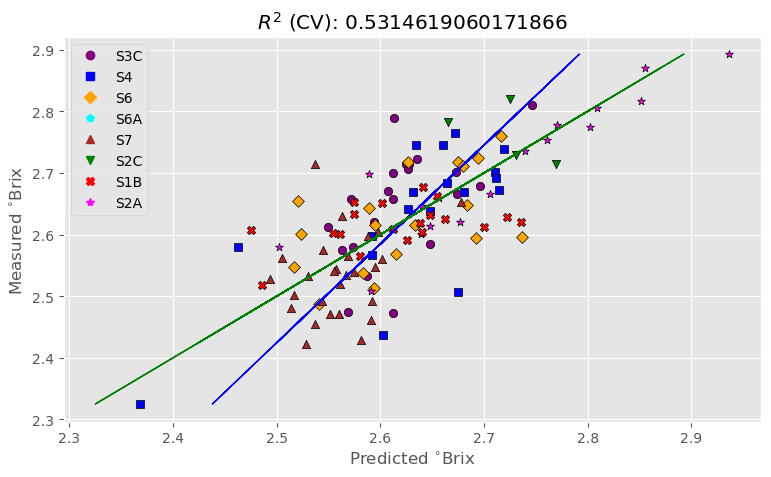

In [20]:
file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\ldmc.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_ldmc,                         
                             ncomp, labels_ldmc, file_name_sla)

In [21]:
optimal_pls = PLSRegression(n_components = 14)
optimal_pls.fit(opt_Xc, y_ldmc.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(b_name)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

(68,) (68,)


array([ 0.01720829,  0.010662  , -0.01975065,  0.01991796,  0.01789968,
        0.01015822, -0.01119669,  0.01852358, -0.0172847 , -0.02611343,
       -0.00086569, -0.00347566, -0.01081627, -0.0134612 ,  0.01938524,
       -0.00080843,  0.00992455,  0.01755073,  0.01169807, -0.01964621,
       -0.02472092,  0.01584184, -0.0127549 , -0.01773485,  0.0080796 ,
       -0.01657785,  0.01637211,  0.02021888,  0.01944128,  0.02220028,
        0.02063484, -0.01926012,  0.0336401 ,  0.03160281,  0.01704362,
        0.02570777,  0.03138547, -0.00737566,  0.02995228, -0.0082799 ,
        0.04273171,  0.03029803,  0.03395239,  0.01827376, -0.02611183,
       -0.01696333, -0.01766567, -0.03430269, -0.02781885, -0.01761985,
        0.01716523,  0.02831037, -0.03546877,  0.01972578, -0.02484544,
        0.04099991, -0.02842266, -0.03630059,  0.02405551,  0.03039251,
       -0.02575044,  0.04142516,  0.0428994 ,  0.05213466,  0.04161289,
       -0.03531394, -0.05144789, -0.06533383])

In [24]:
bands

array(['b120', 'd76', 'd100', 'b64', 'b119', 'd22', 'b4', 'b117', 'd119',
       'd84', 'd86', 'd94', 'd79', 'd36', 'b118', 'd103', 'd2', 'd13',
       'd104', 'd30', 'd58', 'd27', 'd87', 'd69', 'd34', 'd70', 'd111',
       'd60', 'd88', 'd9', 'd16', 'd66', 'd102', 'd73', 'd12', 'd1',
       'd75', 'd120', 'd121', 'd89', 'd45', 'd61', 'd62', 'd117', 'd67',
       'd7', 'd19', 'd21', 'd118', 'd29', 'd116', 'd110', 'd95', 'd113',
       'd44', 'd47', 'd68', 'd57', 'd3', 'd10', 'd15', 'd108', 'd107',
       'd24', 'd106', 'd6', 'd5', 'd4'], dtype='<U4')

In [25]:
optimal_pls.intercept_

array([2.62470061])

In [13]:
df_svc_ldmc['site'][96]

'S2A_Q28'

In [3]:
import pandas as pd

df1 = pd.read_csv(r"E:\wenqu\2026_root\soil core trait_full_edited.csv")
df2 = pd.read_csv(r"D:\wenqu\2024_data\Fw_2024_aboveground\2022_2024_spectral.csv")

# inner join (only matching rows)
df_joined = pd.merge(df1, df2, on="site", how="inner")

df_joined.to_csv(r"E:\wenqu\2026_root\root_trait.csv", index=False)


In [30]:
import pandas as pd
import numpy as np

# ===== 1. file paths =====
input_csv = r"D:\wenqu\2024_data\SVC\update3_vascular\spectral_trait_mean.csv"
# output_csv_all = r"D:\wenqu\2024_data\SVC\update3_vascular\PC_with_zscores.csv"
output_csv_clean = r"D:\wenqu\2024_data\SVC\update3_vascular\PN_without_zscores.csv"

# ===== 2. column name =====
col = "CWM_log10_LNC"   # <-- change this to your column name

# ===== 3. read csv =====
df = pd.read_csv(input_csv)

# make sure column is numeric
df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 4. compute z-score =====
mean = df[col].mean()
std = df[col].std()

df["z_score"] = (df[col] - mean) / std

# ===== 5. flag outliers (|z| > 3) =====
df["outlier"] = df["z_score"].abs() > 3

# ===== 6. remove outliers (optional) =====
df_clean = df[df["outlier"] == False]

# ===== 7. save results =====
# df.to_csv(output_csv_all, index=False)
df_clean.to_csv(output_csv_clean, index=False)

print("Done!")
print("Total rows:", len(df))
print("Outliers removed:", df["outlier"].sum())


Done!
Total rows: 138
Outliers removed: 1
